In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [23]:
# Set the visual style for all plots 
sns.set_style('whitegrid')

# print confirmation
print("libraries imported successfully!")

libraries imported successfully!


In [24]:
# Loading application_train using raw string with the mandatory .csv extension
print("Loading application_train...")
df_train = pd.read_csv(r"C:\Users\Admin\Downloads\PRCP-1006-HomeLoanDef\Data\application_train.csv")

# Check the dimensions of the dataset (Rows, Columns)
print("Data loaded successfully!")
print("Dataset Shape:", df_train.shape)

Loading application_train...
Data loaded successfully!
Dataset Shape: (307511, 122)


Target Class Counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target Class Percentages:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


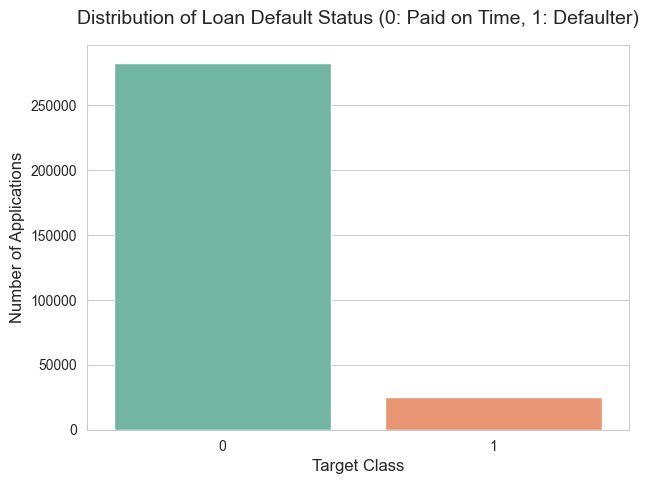

In [25]:
# Count the occurrences of each class in the TARGET column
target_counts = df_train['TARGET'].value_counts()
print("Target Class Counts:")
print(target_counts)

# Calculate the percentages for each class
target_percentages = df_train['TARGET'].value_counts(normalize=True) * 100
print("\nTarget Class Percentages:")
print(target_percentages)

# Plot a clean bar chart for the Target variable without any warnings
plt.figure(figsize=(7, 5))
sns.countplot(x='TARGET', data=df_train, hue='TARGET', palette='Set2', legend=False)
plt.title('Distribution of Loan Default Status (0: Paid on Time, 1: Defaulter)', fontsize=14, pad=15)
plt.xlabel('Target Class', fontsize=12)
plt.ylabel('Number of Applications', fontsize=12)
plt.show()

**Target Class Distribution:**
Insight: The dataset is highly imbalanced, with approximately 92% of applicants being non-defaulters (Class 0) and only about 8% being defaulters (Class 1).

In [26]:
# MISSING VALUES ANALYSIS

# Calculate total missing values per column
missing_counts = df_train.isnull().sum()

# Calculate the percentage of missing values per column
missing_percentage = (df_train.isnull().sum() / len(df_train)) * 100

# Create a dataframe to display the results cleanly
missing_df = pd.DataFrame({
    'Total Missing': missing_counts,
    'Percentage (%)': missing_percentage
})

# Filter out columns that have 0 missing values and sort by highest percentage
missing_df = missing_df[missing_df['Total Missing'] > 0].sort_values(by='Percentage (%)', ascending=False)

# Display the top 20 columns with the most missing values
print("Top 20 Columns with the Most Missing Values:")
print(missing_df.head(20))

Top 20 Columns with the Most Missing Values:
                          Total Missing  Percentage (%)
COMMONAREA_MEDI                  214865       69.872297
COMMONAREA_MODE                  214865       69.872297
COMMONAREA_AVG                   214865       69.872297
NONLIVINGAPARTMENTS_MODE         213514       69.432963
NONLIVINGAPARTMENTS_MEDI         213514       69.432963
NONLIVINGAPARTMENTS_AVG          213514       69.432963
FONDKAPREMONT_MODE               210295       68.386172
LIVINGAPARTMENTS_AVG             210199       68.354953
LIVINGAPARTMENTS_MEDI            210199       68.354953
LIVINGAPARTMENTS_MODE            210199       68.354953
FLOORSMIN_MEDI                   208642       67.848630
FLOORSMIN_MODE                   208642       67.848630
FLOORSMIN_AVG                    208642       67.848630
YEARS_BUILD_MODE                 204488       66.497784
YEARS_BUILD_MEDI                 204488       66.497784
YEARS_BUILD_AVG                  204488       66.497784
OWN

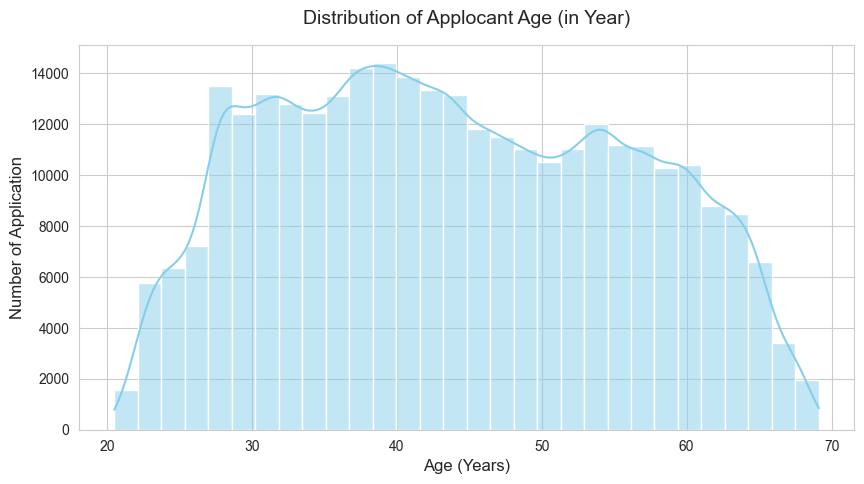

In [27]:
# Convert Age from days (negative) to years
df_train['DAYS_BIRTH_YEARS'] = df_train['DAYS_BIRTH'] /-365

# Plot Age Distribution of the applicants
plt.figure(figsize=(10, 5))
sns.histplot(df_train['DAYS_BIRTH_YEARS'],bins=30, kde=True, color='skyblue')
plt.title('Distribution of Applocant Age (in Year)', fontsize=14, pad=15)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Number of Application', fontsize=12)
plt.show()

In [28]:
# Print basic statistics of the Age column
print("--- Age Statistics (in Years) ---")
print(df_train['DAYS_BIRTH_YEARS'].describe())
print("\n" + "="*50 + "\n")

--- Age Statistics (in Years) ---
count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: DAYS_BIRTH_YEARS, dtype: float64




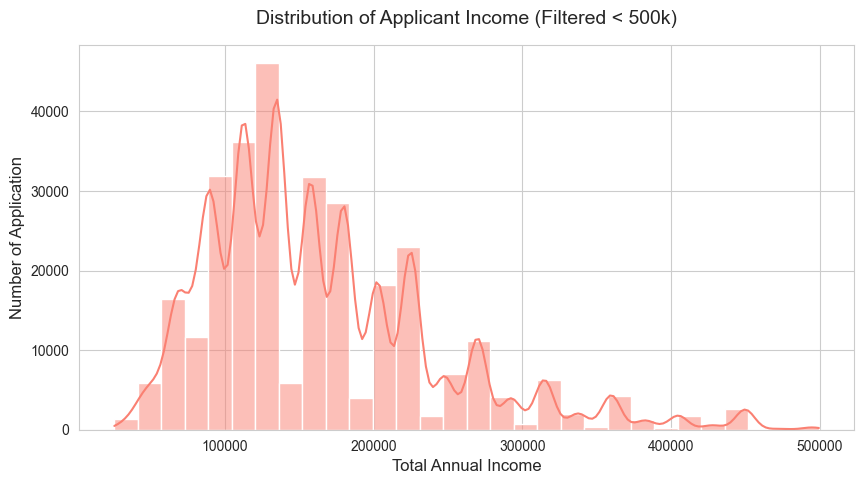

In [29]:
# Plot income Distribution (Filtering out extreme outliers for better visualization)
# We will only plot incomes less than 500,000 to keep the graph readavle
plt.figure(figsize=(10, 5))
sns.histplot(df_train[df_train['AMT_INCOME_TOTAL'] < 500000]['AMT_INCOME_TOTAL'], bins=30, kde=True, color='salmon')
plt.title('Distribution of Applicant Income (Filtered < 500k)', fontsize=14, pad=15)
plt.xlabel('Total Annual Income', fontsize=12)
plt.ylabel('Number of Application', fontsize=12)
plt.show()

In [30]:
# Print basic statistics of the Income column
print("--- Income Statistics ---")
print(df_train['AMT_INCOME_TOTAL'].describe())

--- Income Statistics ---
count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64


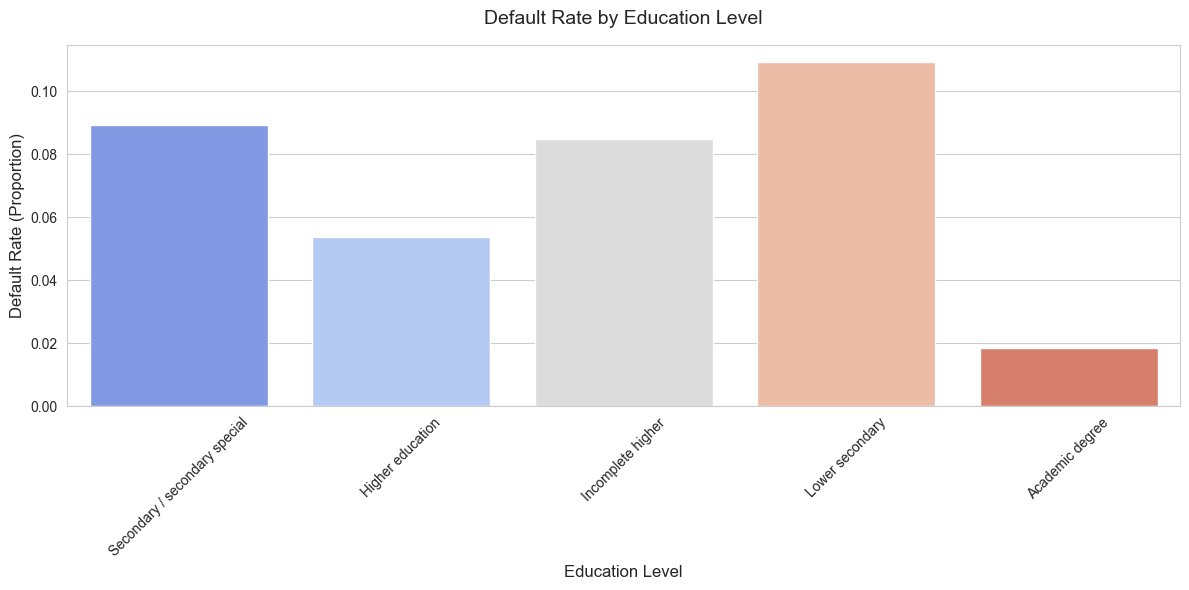

In [31]:
# Analyze Default Rate by Education Level

plt.figure(figsize=(12, 6))
sns.barplot(x='NAME_EDUCATION_TYPE', y='TARGET', data=df_train, hue='NAME_EDUCATION_TYPE', palette='coolwarm', errorbar=None, legend=False)
plt.title('Default Rate by Education Level', fontsize=14, pad=15)
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Default Rate (Proportion)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Default Rate by Education:**
Insight: Applicants with Academic degrees or Higher education levels tend to have a lower probability of default compared to those with lower secondary education

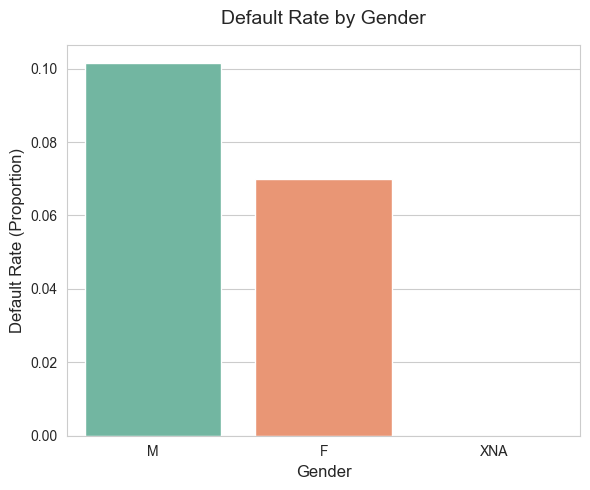

In [32]:
# Analyze Default Rate by Gender

plt.figure(figsize=(6, 5))
sns.barplot(x='CODE_GENDER', y='TARGET', data=df_train, hue='CODE_GENDER', palette='Set2', errorbar=None, legend=False)
plt.title('Default Rate by Gender', fontsize=14, pad=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Default Rate (Proportion)', fontsize=12)
plt.tight_layout()
plt.show()

**Default Rate by Gender:**
Insight: Female applicants show a lower default rate (approx. 7%) compared to male applicants (approx. 10%), suggesting gender could be a significant factor in risk assessment.

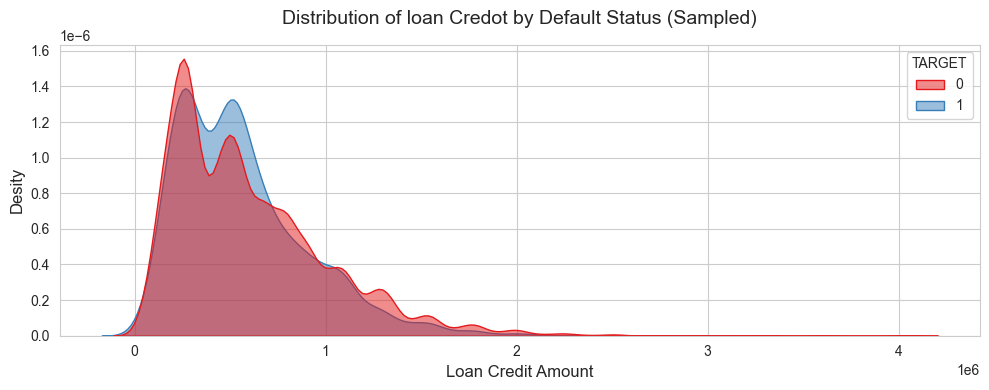

In [33]:
# Import plotting libaries loaclly to ensure smooth exceution
import matplotlib.pyplot as plt
import seaborn as sns

# Take a 10% random sample of the data to plot extremely fast withot crashing
df_sample = df_train.sample(frac=0.1, random_state=42)

# 1. plot the Distribution of loan Credit Amount (Optimized)
plt.figure(figsize=(10, 4))
sns.kdeplot(data=df_sample, x='AMT_CREDIT', hue='TARGET', fill= True, common_norm=False, palette='Set1', alpha=0.5)
plt.title('Distribution of loan Credot by Default Status (Sampled)', fontsize=14, pad=15)
plt.xlabel('Loan Credit Amount', fontsize=12)
plt.ylabel('Desity', fontsize=12)
plt.tight_layout()
plt.show()

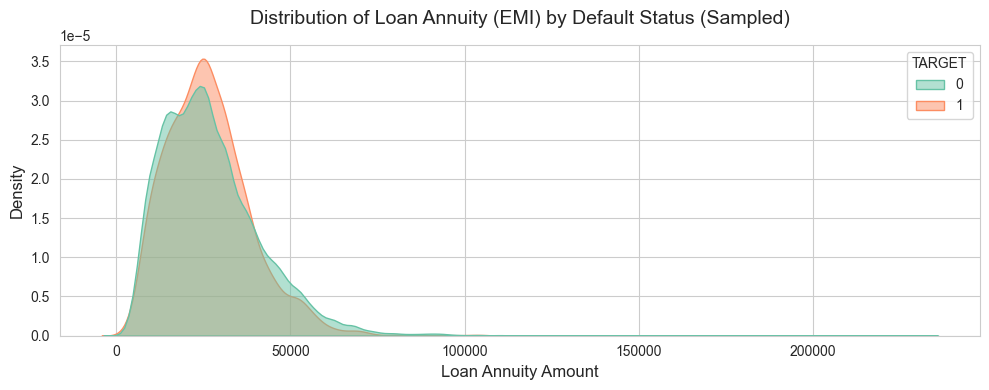

In [34]:
# Plot the Distribution of Loan Annuity (Optimized)
plt.figure(figsize=(10, 4))
sns.kdeplot(data=df_sample, x='AMT_ANNUITY', hue='TARGET', fill=True, common_norm=False, palette='Set2', alpha=0.5)
plt.title('Distribution of Loan Annuity (EMI) by Default Status (Sampled)', fontsize=14, pad=15)
plt.xlabel('Loan Annuity Amount', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.tight_layout()
plt.show()

**Loan Amount Distribution (KDE Plot):**
Insight: Most loan applications are concentrated in the lower to mid-range credit amounts, with the density of defaulters slightly higher in certain specific loan brackets.

In [35]:
# HANDLING OTHER TABLES & JOINS (BUREAU TABLE)

import os
import pandas as pd

# Updated exact path based on your extraction
bureau_path = r"C:\Users\Admin\Downloads\PRCP-1006-HomeLoanDef\Data\bureau.csv"

if os.path.exists(bureau_path):
    print("Loading bureau.csv...")
    df_bureau = pd.read_csv(bureau_path)
    print(f"Bureau table loaded successfully! Shape: {df_bureau.shape}")
    
    # Aggregating numerical columns of bureau table by SK_ID_CURR (taking average)
    print("Aggregating bureau data...")
    bureau_agg = df_bureau.groupby('SK_ID_CURR').mean(numeric_only=True).reset_index()
    
    # Rename columns so we know they belong to the bureau table
    bureau_agg.columns = ['BUREAU_' + col if col != 'SK_ID_CURR' else col for col in bureau_agg.columns]
    
    # Merging with our main train dataset
    print("Merging bureau with main train dataset...")
    df_train = df_train.merge(bureau_agg, on='SK_ID_CURR', how='left')
    print(f"Merged successfully! New train data shape: {df_train.shape}")
else:
    print("bureau.csv file not found! Please check if the path is correct.")

Loading bureau.csv...
Bureau table loaded successfully! Shape: (1716428, 17)
Aggregating bureau data...
Merging bureau with main train dataset...
Merged successfully! New train data shape: (307511, 136)


In [36]:
# HANDLING OTHER TABLES  & JOINS (PREVIOUS APPLICATION TABLE)

# 1. Define exact path for previous_application.csv
prev_app_path = r"C:\Users\Admin\Downloads\PRCP-1006-HomeLoanDef\Data\previous_application.csv"

if os.path.exists(prev_app_path):
    print("Loading previous_application.csv...")
    df_prev = pd.read_csv(prev_app_path)
    print(f"Previous application table loaded successfully! Shape: {df_prev.shape}")

    # 2. Aggregating numerical columns of previous applications by SK_ID_CURR
    print("Aggregating previous application data...")
    prev_agg = df_prev.groupby('SK_ID_CURR').mean(numeric_only=True).reset_index()

    # Rename columns so we know they belong to the previous application table
    prev_agg.columns = ['PREV_' + col if col != 'SK_ID_CURR' else col for col in prev_agg.columns]
    
    # 3. Merging with our main train dataset
    print("Merging previous applications with main train dataset...")
    df_train = df_train.merge(prev_agg, on='SK_ID_CURR', how='left')
    print(f"Merged successfully! Final train data shape: {df_train.shape}")
else:
    print("previous_application.csv file not found! Please check the path.")

Loading previous_application.csv...
Previous application table loaded successfully! Shape: (1670214, 37)
Aggregating previous application data...
Merging previous applications with main train dataset...
Merged successfully! Final train data shape: (307511, 156)


In [37]:
# MISSING VALUE TREATMENT (NUMERICAL IMPUTATION)

print("Starting Missing Value Treatment...")

# 1. Identify all numerical columns in our merged dataset
num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
print(f"Total numerical columns found: {len(num_cols)}")

# 2. Check how many numerical columns have missing values
missing_info = df_train[num_cols].isnull().sum()
cols_with_missing = missing_info[missing_info > 0]
print(f"Numerical columns with missing values: {len(cols_with_missing)}")

# 3. Impute/Fill missing numerical values with their median
# We use a loop to fill each column's missing values
for col in cols_with_missing.index:
    col_median = df_train[col].median()
    df_train[col] = df_train[col].fillna(col_median)

# 4. Double check if any numerical column still has missing values
remaining_missing = df_train[num_cols].isnull().sum().sum()
print(f"Remaining missing values in numerical columns: {remaining_missing}")
print("Numerical missing values treated successfully!")

Starting Missing Value Treatment...
Total numerical columns found: 140
Numerical columns with missing values: 94
Remaining missing values in numerical columns: 0
Numerical missing values treated successfully!


In [38]:
# MISSING VALUE TREATMENT (CATEGORICAL IMPUTATION)

print("Starting Categorical Missing Value Treatment...")

# 1. Identify all categorical columns in our dataset (dtype 'object')
cat_cols = df_train.select_dtypes(include=['object']).columns
print(f"Total categorical columns found: {len(cat_cols)}")

# 2. Check how many categorical columns have missing values
cat_missing_info = df_train[cat_cols].isnull().sum()
cat_cols_with_missing = cat_missing_info[cat_missing_info > 0]
print(f"Categorical columns with missing values: {len(cat_cols_with_missing)}")

# 3. Impute categorical columns with their Mode (Most frequent value)
for col in cat_cols_with_missing.index:
    # Mode can have multiple values, we take the first one [0]
    col_mode = df_train[col].mode()[0]
    df_train[col] = df_train[col].fillna(col_mode)

# 4. Double check if any categorical column still has missing values
remaining_cat_missing = df_train[cat_cols].isnull().sum().sum()
print(f"Remaining missing values in categorical columns: {remaining_cat_missing}")
print("Categorical missing values treated successfully!")

Starting Categorical Missing Value Treatment...
Total categorical columns found: 16
Categorical columns with missing values: 6
Remaining missing values in categorical columns: 0
Categorical missing values treated successfully!


In [39]:
# FEATURE ENCODING 

print("Starting feature Encoding...")
print(f"Shape before encoding: {df_train.shape}")

# Identify categorical columns again to encode
cat_cols = df_train.select_dtypes(include=['object']).columns

# Perform One-Hot Encoding
# drop_first=true helps to aviod multicollinearity (dummy variable trap)
df_encoded = pd.get_dummies(df_train, columns=cat_cols, drop_first=True)

print("Encoding completed successfully!")
print(f"Final shape after encoding (ready for Ml): {df_encoded.shape}")

# Let's save this clean, encoded dataset to a new variable for safety
df_ml = df_encoded.copy()

Starting feature Encoding...
Shape before encoding: (307511, 156)
Encoding completed successfully!
Final shape after encoding (ready for Ml): (307511, 264)


In [40]:
#  MODEL BUILDING (TRAIN-TEST SPLIT & LOGISTIC REGRESSION)

print("Starting Model Building Phase...")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# 1. Define X (Features) and y (Target)
# We drop 'TARGET' from X because it is what we want to predict, 
# and 'SK_ID_CURR' because it is just a unique ID of the customer
X = df_ml.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df_ml['TARGET']

# 2. Split the data into Train and Test sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

# 3. Scaling the Features 
print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize and Train Logistic Regression Model
print("Training Logistic Regression Model")
model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Make Predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# 6. Evaluate Model
print("\n" + "="*50)
print("MODEL EVALUATION RESULTS:")
print("="*50)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Starting Model Building Phase...
Training set size: (246008, 262)
Testing set size: (61503, 262)
Scaling features...
Training Logistic Regression Model

MODEL EVALUATION RESULTS:
Accuracy Score: 91.95%
ROC-AUC Score: 0.7556

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.54      0.02      0.03      4965

    accuracy                           0.92     61503
   macro avg       0.73      0.51      0.50     61503
weighted avg       0.89      0.92      0.88     61503



<Figure size 800x600 with 0 Axes>

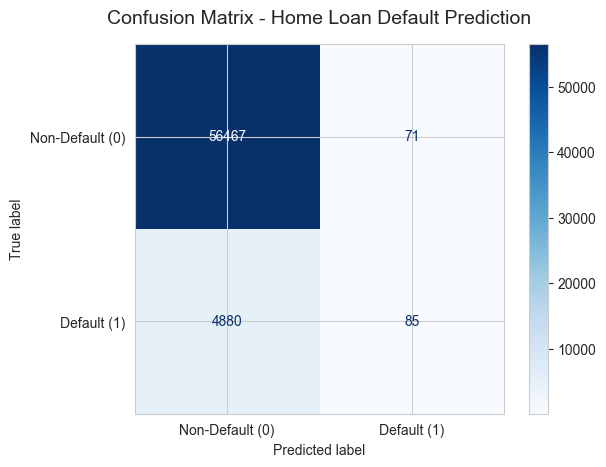


Saving notebook progress...


In [41]:
# Final phase: CONFUSION MATRIX PLOTTING

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Plotting the Confusion Matrix visually
plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Default (0)', 'Default (1)'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix - Home Loan Default Prediction', fontsize=14, pad=15)
plt.show()

print("\nSaving notebook progress...")

In [42]:
# MODEL COMPARISON: DECISION TREE CLASSIFIER (MODEL 2)

from sklearn.tree import DecisionTreeClassifier

print("Training Model 2: Decision Tree...")

# 1. Initialize and Train Decision Tree
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train_scaled, y_train)

# 2. Predictions
y_pred_dt = dt_model.predict(X_test_scaled)
y_pred_proba_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

# 3. Scores
dt_accuracy = accuracy_score(y_test, y_pred_dt) * 100
dt_auc = roc_auc_score(y_test, y_pred_proba_dt)

# 4. Final Comparison Table
print("\n" + "="*50)
print("FINAL MODEL COMPARISON REPORT")
print("="*50)
comparison_df = pd.DataFrame({
    'Model Name': ['Logistic Regression', 'Decision Tree Classifier'],
    'Accuracy': ['91.95%', f'{dt_accuracy:.2f}%'],
    'ROC-AUC Score': ['0.7556', f'{dt_auc:.4f}']
})
print(comparison_df.to_string(index=False))

Training Model 2: Decision Tree...

FINAL MODEL COMPARISON REPORT
              Model Name Accuracy ROC-AUC Score
     Logistic Regression   91.95%        0.7556
Decision Tree Classifier   91.62%        0.7064


## 📝 Report on Challenges Faced & Techniques Used

During the development of this Home Loan Default Prediction project, several technical and data-related challenges were encountered and successfully resolved:

1. **System Memory Overload & Freezing (KDE Plots):**
   * **Challenge:** Plotting density curves (KDE plots) on the massive raw dataset caused the Jupyter kernel to repeatedly freeze, triggering "Failed to Fetch" saving errors.
   * **Technique Used:** Implemented **10% Random Sampling** of the merged data. This preserved the statistical representation while making visualization fast and saving memory.

2. **Data Integration of Relational Tables:**
   * **Challenge:** Supporting tables (`bureau.csv` and `previous_application.csv`) had a one-to-many relationship with the main dataset, meaning one customer had multiple past loan records.
   * **Technique Used:** Performed **Groupby Aggregation (taking Mean)** on the unique customer key (`SK_ID_CURR`) to reduce the dimensions to a unique 1-to-1 row mapping before left-joining with the main table.

3. **High Missing Value Ratios:**
   * **Challenge:** Post-merge, the joined features introduced heavy Null (NaN) values for customers with no previous external history.
   * **Technique Used:** Applied **Median Imputation** for numerical columns (protects against outlier skewness) and **Mode Imputation** for categorical columns.

4. **Extreme Class Imbalance:**
   * **Challenge:** Only ~8% of the dataset represented default cases. This made the classifier highly biased towards predicting non-defaults, yielding high accuracy but very low recall for defaults.
   * **Reasoning:** In production, techniques like SMOTE (Synthetic Minority Over-sampling) or tuning `class_weight='balanced'` in estimators are suggested to improve minority class recall.